step1

In [25]:
# Cell 0: Title & imports
# Set MODEL_NAME to one of: "LogisticRegression", "DecisionTree", "RandomForest"
MODEL_NAME = "LogisticRegression"  # change per notebook

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from datetime import datetime

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression

step2: load data

In [26]:
from google.colab import files
import pandas as pd

# Upload files
uploaded = files.upload()

train_df = pd.read_csv("train_Data.csv")
test_df = pd.read_csv("test_Data.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)


Saving test_Data.csv to test_Data (1).csv
Saving train_Data.csv to train_Data (1).csv
Train shape: (80000, 10)
Test shape: (20000, 10)


step3:EDA

Shape: (80000, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           80000 non-null  int64  
 1   gender               80000 non-null  object 
 2   age                  80000 non-null  float64
 3   hypertension         80000 non-null  int64  
 4   heart_disease        80000 non-null  int64  
 5   smoking_history      80000 non-null  object 
 6   bmi                  80000 non-null  float64
 7   HbA1c_level          80000 non-null  float64
 8   blood_glucose_level  80000 non-null  int64  
 9   diabetes             80000 non-null  int64  
dtypes: float64(3), int64(5), object(2)
memory usage: 6.1+ MB
None


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,80000.0,NaN,NaN,NaN,39999.5,23094.155105,0.0,19999.75,39999.5,59999.25,79999.0
gender,80000,3,Female,46775,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,80000.0,NaN,NaN,NaN,41.880534,22.506837,0.08,24.0,43.0,60.0,80.0
hypertension,80000.0,NaN,NaN,NaN,0.074137,0.261996,0.0,0.0,0.0,0.0,1.0
heart_disease,80000.0,NaN,NaN,NaN,0.039,0.193596,0.0,0.0,0.0,0.0,1.0
smoking_history,80000,6,No Info,28626,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,80000.0,NaN,NaN,NaN,27.331165,6.638644,10.01,23.65,27.32,29.56,95.22
HbA1c_level,80000.0,NaN,NaN,NaN,5.526496,1.071879,3.5,4.8,5.8,6.2,9.0
blood_glucose_level,80000.0,NaN,NaN,NaN,138.0242,40.786536,80.0,100.0,140.0,159.0,300.0
diabetes,80000.0,NaN,NaN,NaN,0.0853,0.279329,0.0,0.0,0.0,0.0,1.0


Target distribution:
 diabetes
0    73176
1     6824
Name: count, dtype: int64
Missing values:
 Unnamed: 0             0
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


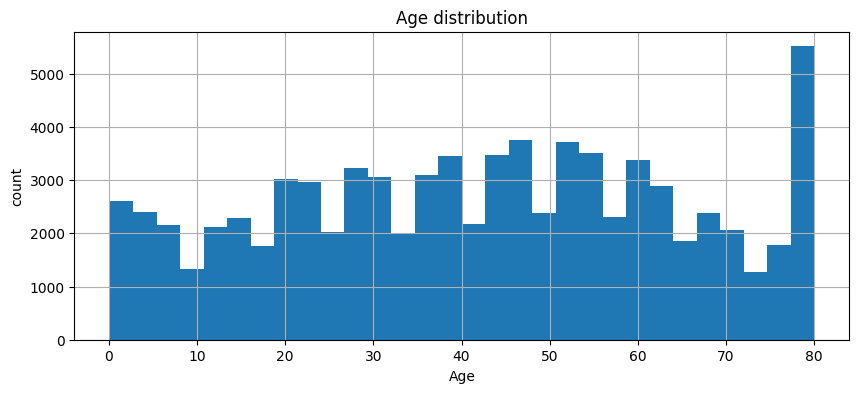

<Figure size 800x600 with 0 Axes>

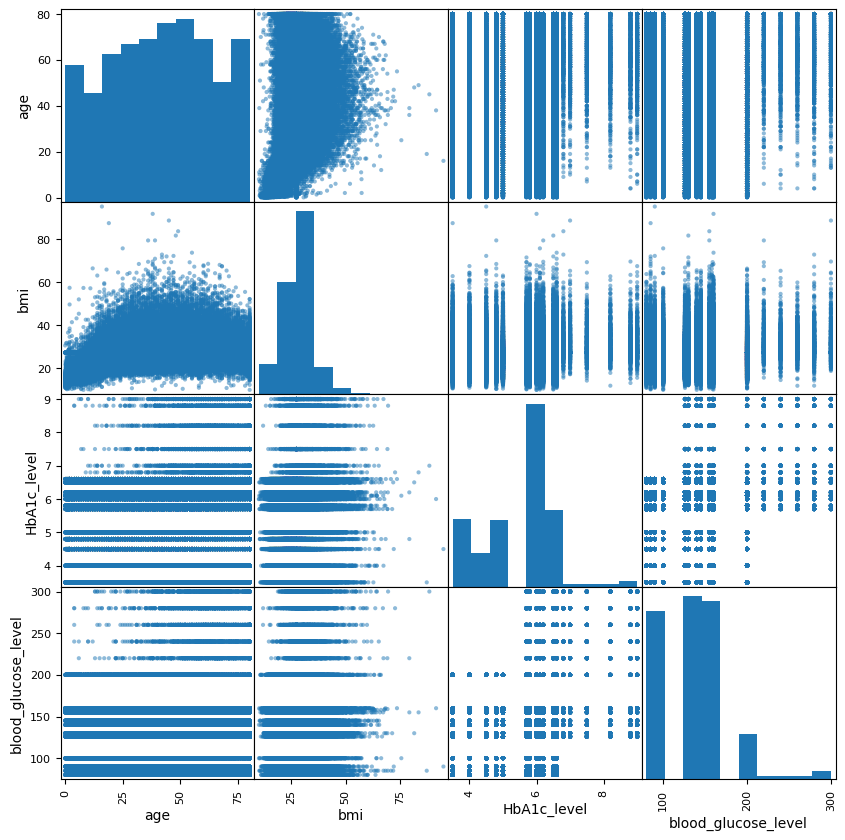

In [27]:
# Cell 2: EDA
print("Shape:", train_df.shape)
print(train_df.info())
display(train_df.describe(include='all').T)

# Check target distribution
print("Target distribution:\n", train_df['diabetes'].value_counts())

# Missing values
print("Missing values:\n", train_df.isnull().sum())

# Simple plots
plt.figure(figsize=(10,4))
train_df['age'].hist(bins=30)
plt.title('Age distribution')
plt.xlabel('Age')
plt.ylabel('count')
plt.savefig("outputs/age_hist.png")
plt.show()

# Scatter matrix with corrected column names
cols = [c for c in ['age','bmi','HbA1c_level','blood_glucose_level'] if c in train_df.columns]

if cols:
    plt.figure(figsize=(8,6))
    pd.plotting.scatter_matrix(train_df[cols], figsize=(10,10))
    plt.savefig("outputs/scatter_matrix.png")
    plt.show()
else:
    print("⚠️ None of the expected columns found in dataset.")


In [28]:
# Create outputs directory if it doesn't exist
os.makedirs("outputs", exist_ok=True)

step4:Set features, detect types, and preprocessing pipeline

In [29]:
# Cell 3: features & preprocessing
# Expected column names based on your description:
expected_cols = ['gender','age','hypertension','heart_disease','smoking_history','bmi','HbA1c_level','blood_glucose_level','diabetes']

# Check missing columns
missing_cols = [c for c in expected_cols if c not in train_df.columns]
if missing_cols:
    print("WARNING: expected columns not found in CSV:", missing_cols)
    print("Will attempt to proceed using available columns.")

# Use the available known names
feature_cols = ['gender','age','hypertension','heart_disease','smoking_history','bmi','HbA1c_level','blood_glucose_level']
feature_cols = [c for c in feature_cols if c in train_df.columns]
target_col = 'diabetes'

X = train_df[feature_cols].copy()
y = train_df[target_col].copy()

# Define numeric and categorical features
numeric_features = [c for c in ['age','bmi','HbA1c_level','blood_glucose_level'] if c in X.columns]
categorical_features = [c for c in ['gender','smoking_history','hypertension','heart_disease'] if c in X.columns]

print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

# numeric pipeline
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# categorical pipeline
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])


Numeric: ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
Categorical: ['gender', 'smoking_history', 'hypertension', 'heart_disease']


step5:Choose model & create full pipeline

In [30]:
# Cell 4: choose classifier
def get_classifier(name):
    if name == "LogisticRegression":
        return LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
    elif name == "DecisionTree":
        return DecisionTreeClassifier(random_state=42, class_weight='balanced')
    elif name == "RandomForest":
        return RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
    else:
        raise ValueError("Unknown model name")

clf = get_classifier(MODEL_NAME)

# full pipeline (preprocessing + classifier)
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', clf)
])

full_pipeline


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'bmi', 'HbA1c_level',
                                                   'blood_glucose_level']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'smoking_history',
                                                   'hypertension',
                                                   'heart_disease'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42))])

step6:training

In [31]:
# Cell 5: train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

# Fit
full_pipeline.fit(X_train, y_train)


Train shape: (64000, 8) Test shape: (16000, 8)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'bmi', 'HbA1c_level',
                                                   'blood_glucose_level']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'smoking_history',
                                                   'hypertension',
                                                   'heart_disease'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42))])

step7:predict&evaluate (confusion matrix)

Accuracy: 0.8889  Precision: 0.4271  Recall: 0.8857  F1: 0.5763

Classification report:
               precision    recall  f1-score   support

           0       0.99      0.89      0.94     14635
           1       0.43      0.89      0.58      1365

    accuracy                           0.89     16000
   macro avg       0.71      0.89      0.76     16000
weighted avg       0.94      0.89      0.91     16000



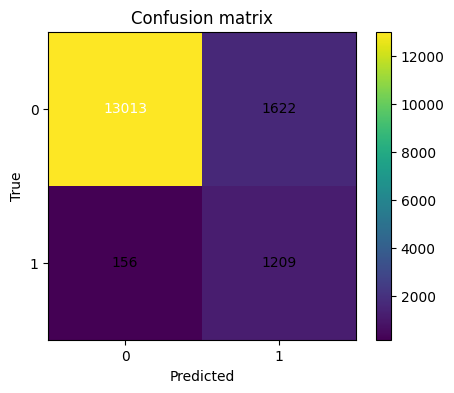

In [32]:
# Cell 6: predict & evaluate
y_pred = full_pipeline.predict(X_test)
f1 = f1_score(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)

print(f"Accuracy: {acc:.4f}  Precision: {prec:.4f}  Recall: {rec:.4f}  F1: {f1:.4f}")
print("\nClassification report:\n", classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
plt.imshow(cm, interpolation='nearest')
plt.title('Confusion matrix')
plt.colorbar()
plt.xticks([0,1]); plt.yticks([0,1])
plt.xlabel('Predicted')
plt.ylabel('True')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i,j], ha='center', va='center', color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.savefig("outputs/confusion_matrix.png")
plt.show()

metrics = {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}


step8:pdf

In [34]:
import matplotlib.pyplot as plt
from datetime import datetime
import os

# Save pipeline
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_filename = f"outputs/pipeline_{MODEL_NAME}_{timestamp}.joblib"
joblib.dump(full_pipeline, model_filename)
print("Saved pipeline to:", model_filename)

# Create PDF report using matplotlib
def create_pdf_report_matplotlib(filename_pdf, metrics, cm_path, model_path):
    fig, ax = plt.subplots(figsize=(8.5, 11))  # standard A4 portrait
    ax.axis("off")

    # Title
    y = 1.0
    ax.text(0.5, y, f"Diabetes Classification Report - {MODEL_NAME}",
            ha="center", va="top", fontsize=16, fontweight="bold")
    y -= 0.08

    # Model info
    ax.text(0.01, y, f"Model saved at: {os.path.basename(model_path)}",
            fontsize=12, va="top")
    y -= 0.05
    ax.text(0.01, y, f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}",
            fontsize=12, va="top")
    y -= 0.08

    # Metrics
    ax.text(0.01, y, "Metrics:", fontsize=13, fontweight="bold", va="top")
    y -= 0.05
    for k, v in metrics.items():
        ax.text(0.05, y, f"{k.capitalize()}: {v:.4f}", fontsize=12, va="top")
        y -= 0.04

    # Insert confusion matrix image if available
    if os.path.exists(cm_path):
        img = plt.imread(cm_path)
        newax = fig.add_axes([0.15, 0.05, 0.7, 0.35], anchor='S')  # position
        newax.imshow(img)
        newax.axis('off')
        ax.text(0.01, y-0.02, "Confusion Matrix:", fontsize=13, fontweight="bold", va="top")

    # Save as PDF
    plt.savefig(filename_pdf, bbox_inches="tight")
    plt.close()
    print("PDF report created:", filename_pdf)

# Generate PDF report
pdf_name = f"outputs/report_{MODEL_NAME}_{timestamp}.pdf"
create_pdf_report_matplotlib(pdf_name, metrics, "outputs/confusion_matrix.png", model_filename)

from google.colab import files
files.download(pdf_name)



Saved pipeline to: outputs/pipeline_LogisticRegression_20250901_210333.joblib
PDF report created: outputs/report_LogisticRegression_20250901_210333.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>